# Chapter 4 Practical
---
[Original Lab](https://colab.research.google.com/github/fastai/fastbook/blob/master/04_mnist_basics.ipynb)

In [ ]:
from fastai.vision.all import *
matplotlib.rc('image', cmap='Greys')

# Task
### we will create a Model that classify any image as a 3 or 7 from sample of  [MNIST](https://en.wikipedia.org/wiki/MNIST_database) Dataset

In [ ]:
path = untar_data(URLs.MNIST_SAMPLE) # Download the data

In [ ]:
Path.BASE_PATH = path

`ls` to inspect what's in the directory which is a method by fastai. This method returns an object of a special fastai class called `L`, which has all the same functionality of Python's built-in `list`,when printed, it displays the count of items, before listing the items themselves (if there are more than 10 items, it just shows the first few):

In [ ]:
path.ls()

[Path('train'), Path('labels.csv'), Path('valid')]

In [ ]:
(path/'train').ls()

[Path('train/3'), Path('train/7')]

Shows that there's a folders of 3s and 7s

In [ ]:
threes = (path/'train'/'3').ls().sorted()
sevens = (path/'train'/'7').ls().sorted()

In [ ]:
len(threes),len(sevens)

(6131, 6265)

If we print `threes` or `sevens` we will get:
1. 6131 : Number of images that contains number 3 or 7 in this folder
2. path() : files names

`sorted()` Sorts the folders

---
visualize an image from `threes` and `sevens` Using Image from $Python Imaging Library$ (PIL)

In [ ]:
im3_path= threes[3] # INDEX
im3 = Image.open(im3_path)
im3

In [ ]:
im7_path = sevens[7] # INDEX
im7 = Image.open(im7_path)
im7

In a computer, everything is represented as a number. To view the numbers that make up this image, we have to convert it to :
- `Numpy` Array
- `PyTorch` Tensor


In [ ]:
import numpy as np

The `4:10` slice the rows,coluimns from index 4 to 10 (not included)
Same with PyTorch tensor

In [ ]:
np.array(im3) # Numpy array

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 104, 253, 253,
        253, 255, 253, 253, 253, 218,  32,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 178, 248, 252, 252,
        252, 253, 252, 252, 252, 252, 215,  34,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 186, 252, 252, 252,
        252, 253, 252, 252, 252, 252, 252,  79,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 186, 252, 243, 172,
        172,  39,  39,  39, 219, 252, 252,  79,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  39,  53,  47,   0,
          0,   0,  29, 117, 244, 252, 252,  79,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  54, 208, 252, 252, 252, 184,  21,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         41, 253, 252, 252, 252, 206,  21,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   5,  41, 165,
        252, 253, 252, 252, 252, 227, 131,   9,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 109, 163, 252, 252,
        252, 253, 252, 252, 252, 252, 252, 156,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 186, 252, 252, 252,
        252, 253, 252, 252, 139, 224, 252, 233,  49,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 187, 253, 253, 253,
        253, 134,  77,   0,   0, 130, 253, 253,  93,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0, 108, 162, 184,  68,
         13,   0,   0,   0,  34, 222, 252, 252,  93,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   5,  10,   0,
          0,   0,   0,   0, 200, 252, 252, 166,  10,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  34, 200, 246, 252, 235,  54,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 142, 252, 252, 234,  76,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 168, 128,   0,   0,   0,   0,   3,
         54, 187, 249, 252, 235, 146,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 226, 227, 138,  11,   7,  55, 177,
        252, 253, 252, 237,  75,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0, 202, 248, 252, 184, 174, 252, 252,
        252, 253, 170,  59,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 131, 249, 252, 252, 252, 251,
        238, 107,   6,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [ ]:
tensor(im3)

tensor([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
           0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 104, 253, 253, 253,
         255, 253, 253, 253, 218,  32,   0,   0,   0,   0,   0,   0,   0,   0],
        [  0,   0,   0,   0,   0,   0,   0,   

We can slice the array to pick just the part with the top of the digit in it, and then use a Pandas DataFrame to color-code the values using a gradient, which shows us clearly how the image is created from the pixel values:

In [ ]:
im3_t = tensor(im3)
df = pd.DataFrame(im3_t[4:20,4:23])
df.style.set_properties(**{'font-size':'6pt'}).background_gradient('Greys')


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,104,253,253,253,255,253,253,253,218,32,0,0,0
2,0,0,0,0,0,178,248,252,252,252,253,252,252,252,252,215,34,0,0
3,0,0,0,0,0,186,252,252,252,252,253,252,252,252,252,252,79,0,0
4,0,0,0,0,0,186,252,243,172,172,39,39,39,219,252,252,79,0,0
5,0,0,0,0,0,39,53,47,0,0,0,29,117,244,252,252,79,0,0
6,0,0,0,0,0,0,0,0,0,0,54,208,252,252,252,184,21,0,0
7,0,0,0,0,0,0,0,0,3,41,253,252,252,252,206,21,0,0,0
8,0,0,0,0,0,0,5,41,165,252,253,252,252,252,227,131,9,0,0
9,0,0,0,0,0,109,163,252,252,252,253,252,252,252,252,252,156,0,0


The background white pixels are stored as the number 0, black is the numbers 255, and gray are between 0-255, The dimension of this image is 28x28 for a total 784 pixels.

# How computer might be able to recognize different digits?

Computers relies on pixel positions having similar intensities.

## 1- Pixel Similarity
Starting with **Baseline** which is the average pixel value for the 3s and 7s

### Steps :   
1. Stack all the 3s in one Tensor, similar to what we did with one image but with `Python list comperhension` to create a plain list of the single image tensors

2. For every pixel position in 3s and 7s we will calculate the **average** over all the images of the intensity of that pixel. To do that we must combine all the images in this list into single **Three-dimensional tensor (Rank 3 tensor)** using `stack` function from PyTorch.


>EX on list comperhension
```python
new_list = [f(i) for i in list1 if i>0]
```
- `list1` : List we are iterating over
- `if i>0` : Filter
- `f(i)` : applying a function or anything to do for each element

### Step 1 : Stack all the 3s & 7s in one Tensor

In [ ]:
three_tensors = [tensor(Image.open(i))for i in threes]

In [ ]:
sevens_tensors = [tensor(Image.open(i)) for i in sevens]

In [ ]:
len(three_tensors),len(sevens_tensors) # Total images

(6131, 6265)

<Axes: >

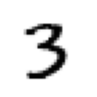

In [ ]:
show_image(three_tensors[1]) # show_image function from fastai

`float()` : converting integer pixels into floating numbers to make the computer handle more precise math.(called cast)

Divided by `/255` : If we feed a network the number `255`, and it multiplies it by a weight, the result becomes massive. We want smaller numbers ANN can handle easily.


The most important attribute of a tensor is its **Shape** it tells us size of each axis:
```python
stacked_threes.shape
```
* `6131`: Total Images
* `28`: Height
* `28`:Width

```python
len(stacked_threes.shape)
stacked_threes.ndim # Both are same
```
* `3` Tensor's rank : number of axes or dimension in a tensor

In [ ]:
stacked_threes = torch.stack(three_tensors,).float()/255 # Stacking 3s
stacked_threes.shape

torch.Size([6131, 28, 28])

In [ ]:
len(stacked_threes.shape)

3

In [ ]:
stacked_sevens = torch.stack(sevens_tensors).float()/255 # Stacking 7s
stacked_sevens.shape

torch.Size([6265, 28, 28])

In [ ]:
stacked_sevens.ndim

3

### Step 2 : Avg

<Axes: >

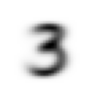

In [ ]:
mean_3 = stacked_threes.mean(0) # Baseline image
show_image(mean_3)

<Axes: >

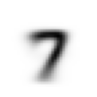

In [ ]:
mean_7 = stacked_sevens.mean(0) #Baseline image
show_image(mean_7)

This is the **ideal** number 3 and 7 or our **Baseline avg** that we will compare it with the model's result to evaluate if the result is good or bad

- Low Number = Close match (Low Error)
- High Number = Bad match (High Error).

---
How can we calculate,How similar a particular image is to each of our ideal digits **(Distance/error)**?

The problem if we used only subtraction we might get a **Negative number** : 200 - 250 = -50

The solution : two ways to handle negatives

1. **L1 Norm** (Mean absolute error) MAE
    - We take the abs value
    - abs(200 - 250) = 50

2. **L2 Norm** (Root Mean Squared Error) RMSE
    - Square the difference
    - (200 - 250)^2 = 2500

NOTE:
MSE(Mean Squared Error):  penalizes big mistakes heavily (discussed later)



(<Axes: title={'center': 'ideal image for 3'}>,
 <Axes: title={'center': 'sample from 3s'}>)

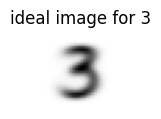

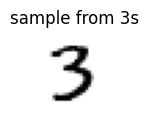

In [ ]:
a_3 = stacked_threes[1]
a_7 = stacked_sevens[1]
show_image(mean_3,title='ideal image for 3'),show_image(a_3,title='sample from 3s')


Using `F` function from PyTorch

In [ ]:
print(f"The L1 Norm for a_3 image with ideal avg = {F.l1_loss(a_3,mean_3):.4f}\n The L2 Norm for a_7 image with ideal avg = {F.mse_loss(a_7,mean_7).sqrt():.4f}")


The L1 Norm for a_3 image with ideal avg = 0.1114
 The L2 Norm for a_7 image with ideal avg = 0.2585


In [ ]:
# The "Wrong" Comparison
print(f"Distance between a_3 and the Ideal 7: {F.l1_loss(mean_7, a_3):.4f}")

Distance between a_3 and the Ideal 7: 0.1586


> The comparison above shows that if the model prediction far from the AVG(ideal 7) we'll get a Bad match (High Error)




---
# Numpy Arrays & PyTorch Tensors

* `Numpy` is a scientific and numeric programming library in
Python allows using a **numpy array** which is a multidimensional table of data, And has variety of operators and methods can run fast
> Doesn't support the GPU or calculating the gradients

* `PyTorch` is a DL framework have **tensors** which is multidimensional table of data with the same type for all components.
>Tensors have additional capabilities and support the GPU means can run faster and can automatically calculate derivatives of these operations.

In [ ]:
data = [[1,2,3],[4,5,6]]
data_Array = np.array(data) #NUMPY
data_Tensor = torch.tensor(data) #PYTORCH

In [ ]:
data_Array

array([[1, 2, 3],
       [4, 5, 6]])

In [ ]:
data_Tensor

tensor([[1, 2, 3],
        [4, 5, 6]])

### Operations on `tensors`
> Syntax and results are identical for numpy

In [ ]:
data_Tensor[1] # indexing

tensor([4, 5, 6])

In [ ]:
data_Tensor[:,1] # Slicing [all rows,col index 1]

tensor([2, 5])

(`[start:end]` with `end` being excluded)

In [ ]:
data_Tensor[1,0:2]

tensor([4, 5])

Standard operators such as `+`, `-`, `*`, `/`:

In [ ]:
data_Tensor +1

tensor([[2, 3, 4],
        [5, 6, 7]])

In [ ]:
data_Tensor -1

tensor([[0, 1, 2],
        [3, 4, 5]])

In [ ]:
data_Tensor**2

tensor([[ 1,  4,  9],
        [16, 25, 36]])

# Computing a metrics Using Brodcasting

**Metric** is a number that is calculated based on model's prediction, and correct ground truth (label), in order to tell us how good our model is. we could use `MSE` or `MAE` or `RMSE` and take avg over the whole dataset,However, neither of them are very understandable to most people, Instead we use **Accuracy** as metric for *Classification models*

We calculate the **Metric** over a **Validation set** to find the right fit for our data and avoid the **Overfitting problem**.

Starting with creating a tensors of 3s and 7s from same dir. These tens we will use to calculate the metric



In [ ]:
valid_threes_tens = torch.stack([tensor(Image.open(i)) for i in ((path/'valid'/'3').ls())])

valid_sevens_tens = torch.stack([tensor(Image.open(i)) for i in ((path/'valid'/'7').ls())])

In [ ]:
valid_threes_tens = valid_threes_tens.float()/255
valid_sevens_tens = valid_sevens_tens.float()/255

In [ ]:
valid_threes_tens.shape,valid_sevens_tens.shape

(torch.Size([1010, 28, 28]), torch.Size([1028, 28, 28]))

* 1010 Images
* 28x28 Shape



In [ ]:
def mnist_distance(a,b): return (a-b).abs().mean((-1,-2))
F.l1_loss(a_3,mean_3)

tensor(0.1114)

In [ ]:
mnist_distance(a_3,mean_3)

tensor(0.1114)

In [ ]:
F.l1_loss(a_3,mean_3)

tensor(0.1114)

The functions `def mnist_distance(a,b)` & `F.l1_loss` both calculate the **L1 NORM (MAU)** but they differ in how they handle **Batches of data**(multiple images at once).

`F.l1_loss` : Return a single scalar, And it takes the avg of every single pixel in the entire batch. Used in *training* (Backpropagation needs one final Loss number). That means we cannot compare two images beacuse the errors are merged.

`def mnist_distance(a,b)` : It allows us to calculate the distance for every image in the validation set simultaneously without using a slow `for loop`.

- `mean((-1,-2)`: The **Tuple** represnts a (Batch_Size, Height, Width).

  - `-1`: Selects *the last* dimension (Width).

  - `-2`: Selects the *second-to-last* dimension (Height).

- `abs` Method applies to each indivisual element in the tensor we get 1010 matrices of abs values.

In [ ]:
valid_threes_tens.shape,mean_3.shape # Different shapes

(torch.Size([1010, 28, 28]), torch.Size([28, 28]))

**Brodcasting** Means PyTorch automatically expand the tensor with  **smaller rank** to have same size as the one with **larger rank**.
For instance:
```python
tensor([1,2,3]) 1 tensor(1)
# Output : [2,3,4]
```

in the next code:
`valid_threes_tens` has shape (1010, 28, 28). (A stack of 1,010 images).

`mean_3` has shape (28, 28). (Just 1 image).
PyTorch copies `mean3` 1010 times to make them ideal for calculation
> It doesn't copy the data in memory it just pretends to copy it.

> We’ll be learning lots in Chapter 17, and will be practicing it regularly too.

---


In [ ]:
valid_threes_tens_distance = mnist_distance(valid_threes_tens,mean_3)


In [ ]:
valid_threes_tens_distance,valid_threes_tens_distance.shape

(tensor([0.1200, 0.1257, 0.1222,  ..., 0.1495, 0.1101, 0.1086]),
 torch.Size([1010]))

We can use `mnist_distance(a,b)` to figure whether the an image is 3 or not by this logic: if the **distance** between the digit given x and the ideal 3 **(Mean image)** is less than the distance to the ideal 7, then it's a 3

In [ ]:
def is_3(x): return mnist_distance(x,mean_3) < mnist_distance(x,mean_7)

In [ ]:
# EX
is_3(a_3),is_3(a_3).float()

(tensor(True), tensor(1.))

the respone is `True`: 1

We can test it on the full validation set

In [ ]:
is_3(valid_threes_tens)

tensor([True, True, True,  ..., True, True, True])

 Calculating the **Accuracy**

In [ ]:
accuracy_3s = is_3(valid_threes_tens).float().mean()
accuracy_7s = (1 - is_3(valid_sevens_tens).float()).mean()
accuracy_3s,accuracy_7s,(accuracy_3s + accuracy_7s)/2

(tensor(0.9168), tensor(0.9854), tensor(0.9511))

Next we're trying a system that does the some **Real learning**, that can automatically modify itself to improve its performance
- **Training** process
- SGD
---
# Stochastic Gradient Descent (SGD)

Instead of trying to find the **similarity** between an image and an **ideal image (mean)***, we could look at each indivisual pixel and come up with a set of **weights** for each one,Highest weights are associated with those most likely to be black for a paricular category. For instance, pixels toward the bottom right are not very likely to be activated for a 7, so they should have a low weight for a 7, but they are likely to be activated for an 8, so they should have a high weight for an 8.
This can be represented as a function and set of weight values for each possible category

```python
def prob_eight(x,w): return (x*w).sum() # The prob of being num 8
```
Assuming that `x` is the image vector and the `w` is the weight vector, if we have this function we just need a way to update the weights to make them a better. With such an approach, we can repeat that step a number of times to find the best parameter (weight)

We want specific value thats for vector `w` that causes the result of our function to be high for imgages that are actually 8s, and low for images that are not.

searching for best vector `w` is a way to search for the best function for recognizing 8s


#### Required steps to turn this function into a **Machine Learning classifier** :

1. Initialize the weights (Random weights)
2. For each image, use these weights to **predict** whether it appears to be a 3 or a 7.
3. Based on these predictions, calculate the how good the model is **(Its LOSS)**
4. Calculate the gradient, which measures for each weight,how changing that weight would change the loss
5. change all the weights based on that calculation.
6. Step (that is, change) all the weights based on that calculation.
7. Iterate until you decide to stop the training process (for instance, because the model is good enough or you don't want to wait any longer).

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Seven steps for gradient descent process">
</div>

> There are many ways to do each of these steps, will learn about them later in this book
---
### Basic principles

* **Initialize** : We Initialize the parameters with **random values**

* **Loss**: We need a number that will return a number that is small if the performance of the model is **good**

* **Step**(learning rate): A way to figure out whether a weight should be increased or decreased a bit, Try to increase the weight by a small amount, and see if the loss goes up or down. Once you find the correct direction, you could then change that amount by a bit more, and a bit less, until you find an amount that works well. However, This is slow, as we will see, the **calculas** allows us to directly figure out in which direcion, and by roughly how much, to change each weight, without having to try all these small changes. we do this by calculating the **gradients**. This is just a *performance optimization*.

* **Stop** : We train for the chosen number of epochs, stopping early if the accuracy starts to drop or we run out of time

> Before applying these steps to our image classifier, let's illustrate what they look like in a simpler case. First we will define a very simple function, the quadratic—let's pretend that this is our loss function, and x is a weight parameter of the function:


In [ ]:
def f(x):return x**2

In [ ]:
def plot_function(func):
    x = np.linspace(-2,2,100)
    y = func(x)
    #plot
    plt.figure(figsize=(6, 5))
    plt.plot(x,y)
    plt.xlabel('x')
    plt.ylabel('x**2')
    plt.scatter(-1.5,f(-1.5),color= 'red')
    plt.show()



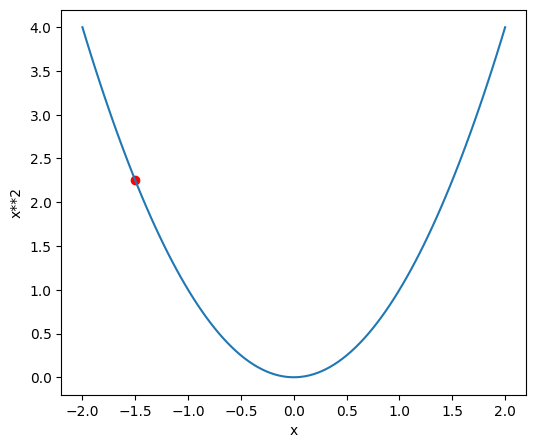

In [ ]:
plot_function(f)

the *Adjusment* is to change the weight by a little in the opposite direction of the slope, calculate our loss and adjusment again untill we reach the **Global minima** which is nearly zero.


<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Step">
</div>

---
## Calculating Gradients
We use calculus as a **performance optimization**;it allows us to more quickly calculate whether our **loss** will go up or down. In other word the **gradients** tell us how much we have to change the each **weight** to make our model better.

### Definitions of derivative
- The derivative is the instantaneous rate of change of a function at a specific point.
- Derivative of a function it measures how much the value of the function changes when the input changes by a very small amount.

>The gradient (slope) is defined as *Rise/Run*, the change in value of a function divided by the change of the parameter. Now we know how our function will change, then we know what we need to change to make it smaller.

>This is the key to machine learning: having a way to change the parameters of a function to make it smaller. Calculus provides us with a computational shortcut, the derivative, which lets us directly calculate the gradients of our functions.

Note that our function has **lots** of weight that when we need to adjust, So we will calculate the derivative with respect to one weight, and treat the other as **constant**, then repeat that for each weight.


Pytorch cumputes the gradients of any function.

- `requires_grad_()`: Tells PyTorch to track operations on it for backpropagation
lets use it with our `f()`

In [ ]:
xt = tensor(3.).requires_grad_()
xt

tensor(3., requires_grad=True)

In [ ]:
y_t = f(xt)
y_t

tensor(9., grad_fn=<PowBackward0>)

`backward()` : Calculates the gradients

In [ ]:
y_t.backward()

**backward** refers to *backpropagation*, which is the process of calculating the derivative of each layer
> Disscussed in ch 17 when we calculate gradients of DNN from scratch


view the gradients by using `grad`

In [ ]:
xt.grad

tensor(6.)

what happend is the derivative of `x**2` is `2*x`, and we have `x=3`, so the gradients should be `2*3=6`

- When x = 3, the function is increasing at a speed of 6 per unit of x.
  - `x`: weight
  - `y_t`: loss
  - `ydash_t`: gradient
  > If I increase this weight a little, the loss will increase about 6 times that amount.
---
What if we have more than one weight?

In [ ]:
def f_scalar(x): return (x**2).sum() # sum() takes a vector and sum all the values

In [ ]:
xt = tensor([3.,4.,10.]).requires_grad_()
xt

tensor([ 3.,  4., 10.], requires_grad=True)

In [ ]:
y_t = f_scalar(xt)

In [ ]:
y_t


tensor(125., grad_fn=<SumBackward0>)

In [ ]:
y_t.backward() # backproagation calculates the derivatives of each weight
xt.grad # view the gradients

tensor([ 6.,  8., 20.])

The **Gradients** only tell us the `slope` of a funcion, they dont tell us exactly how far to adjust the parameters. But it gives us some ideas of how far; if the slope is very large, then we have to adjust the weights, if the slope is very small, that may suggest that we are close to the optimal value (**Global minima**).

## Stepping with a Learning Rate
 **Learning rate** is a small number often between `0.001` and `0.1`, it could be anything. Controls how big a step we take when updating weights
## Update Formula:
 ```python
 w = w - lr * w.grad
 ```


### simple ex shows how the update process works:
---
### Given:
- Initial value: `x = 3`
- Function: `f(x) = x²`
- Learning rate: `lr = 0.1`

### Step 1: Compute the Gradient
The derivative of the function is:

f′(x) = 2x

At `x = 3`:

grad = 2 × 3 = 6

### Step 2: Update the Parameter
We update `x` using gradient descent:

new_x = 3 − 0.1 × 6 = 2.4

So, `x` decreases from `3` to `2.4`.

### Step 3: Check the Loss

**Before update:**

f(3) = 3² = 9

**After update:**

f(2.4) = 2.4² = 5.76

### Result:
Since `5.76 < 9`, the loss has decreased.

This means the update moved `x` closer to the minimum of the function.

---
This knows as *Stepping parameters*, we subtract `w * gradients` from the parameter to update it. This allows us to adjust the parameter in the direction of the slope by **increasing** the parameter when the slope is **negative** and **decreasing** the parameter when the slope is **positive**

We want to adjust our parameters in the direction of the slope because our goal in deep learning is to minimize the loss.

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Stepping">
</div>


Picking a learning rate that's too high, it can result in the loss getting worse

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="High Lr">
</div>


Also if it's too high it may **Bounce** around, rather than actually diverging

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Bouncing lr">
</div>

## End-to-End SGD Example

### The problem
Imaging roller coaster(قطار الموت) as it went over the top of a hump. It would start fast, and then get slower as it went up the hill; it would be slowest at the top, and it would then speed up again as it went downhill.

You want to build a model of how the speed changes over time. If you were measuring the speed manually every second for 20 seconds, it might look something like this:

In [ ]:
time = torch.arange(0,20).float()
time

tensor([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10., 11., 12., 13.,
        14., 15., 16., 17., 18., 19.])

In [ ]:
speed = torch.randn(20)*3 + 0.75*(time-9.5)**2 + 1

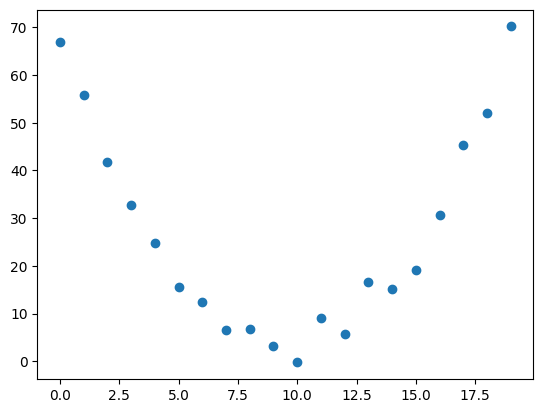

In [ ]:
plt.scatter(time,speed)

Measuring things manually isn't precise, This means it's not easy to answer the question:**what was the roller coaster's speed?** Using `SGD` we can try to find a function that matches our observation.

EX : `a(time)**2 + (b*time) + c`  We want to distinguish clearly function's input (the time when are measuring the coaster's speed) and it's parameter (the values that define which quadratic we're trying).

In [ ]:
def v(t,paramss):
  a,b,c = paramss
  return a*(t**2) + (b*t)+c

We've restricted the problem of finding the best imaginable function that **fits the data**

to find the best quadratic function, we only need to find best values for `a`, `b` and `c`.

We need to define first what we mean by "best." We define this precisely by choosing a loss function, which will return a value based on a prediction and a target.

lower values = better predictons


In [ ]:
def mse(preds,target): return ((preds - target)**2).mean()

### Now lets apply the 7 step process



### step 1 Initailize the prameters
we initialize the parameters to random values, and tell PyTorch that we want to track their gradients, using `requires_grad_`:

In [ ]:
params = torch.randn(3).requires_grad_() # Initail 3 weights with random numbers
params

tensor([-0.9065,  0.6927,  0.4642], requires_grad=True)

In [ ]:
orig_params = params.clone() # clone the orignal params

### step 2 Calculate the predictions

In [ ]:
preds = v(time,params)

Let's create a function to show our predictions

In [ ]:
def show_preds(preds, ax=None):
    if ax is None:
      ax=plt.subplots()[1]

    ax.scatter(time, speed)
    ax.scatter(time, to_np(preds), color='red')
    ax.set_ylim(-300,100) # y axis starts from -500 to 100

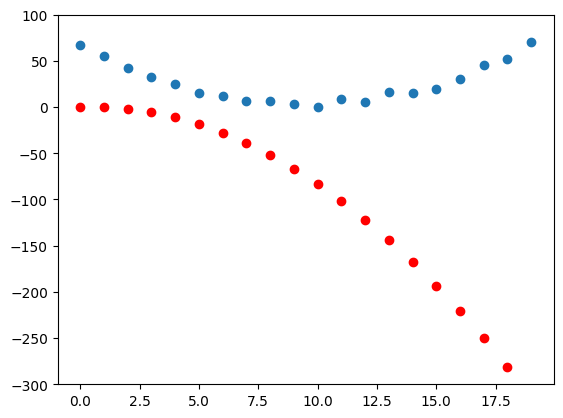

In [ ]:
show_preds(preds)

Our random parameters suggest that the roller coaster will end going backwards, since we have **negative speed**

### Step 3 Calculate the `Loss`

In [ ]:
loss = mse(preds,speed)
loss

tensor(28660.9062, grad_fn=<MeanBackward0>)

The goal is to improve this. To make it close to zero!

### Step 4 Calculate the **gradients**

In [ ]:
loss.backward() # calculate the gradient
params.grad

tensor([-56181.5938,  -3595.5928,   -262.8351])

In [ ]:
params.grad * 1e-5

tensor([-0.5618, -0.0360, -0.0026])

We need to pick a learning rate (Discussed in chapter 5), for now we'll use `0.00001` or 1e-5

In [ ]:
params

tensor([-0.9065,  0.6927,  0.4642], requires_grad=True)

### Step 5 Step the weights
Now we need to update the parameters based on the gradients we just calculated:

In [ ]:
lr = 1e-5
params.data -= lr * params.grad.data
params.grad = None

In [ ]:
preds = v(time,params)
mse(preds,speed)

tensor(5920.5830, grad_fn=<MeanBackward0>)

Let's check on the graph again

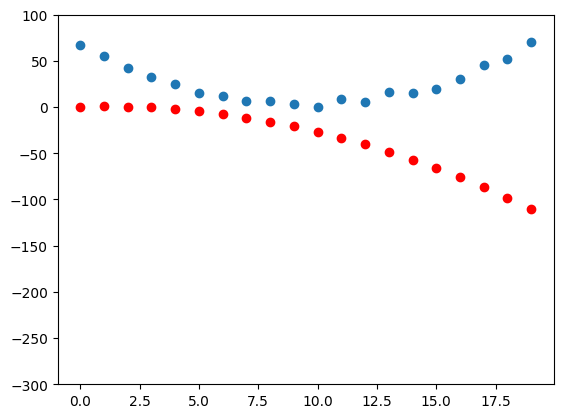

In [ ]:
show_preds(preds)

### Step 6 Repeat the process

In [ ]:
def apply_step(params,prn=True):
  preds = v(time,params) # Forward pass
  loss = mse(preds,speed) # Compute loss
  loss.backward() # Backward pass → compute gradients
  params.data -= lr * params.grad.data # Update weights
  params.grad = None # clear gradients for next iter

  if prn: print(loss.item())
  return preds

In [ ]:
for i in range(10): apply_step(params)

5920.5830078125
1617.415771484375
803.1221923828125
649.0301513671875
619.8682861328125
614.34716796875
613.2994995117188
613.098388671875
613.0575561523438
613.0468139648438


The loss is going down as we hoped!

Each iteration represents an entirely different quadratic function being tried,on the way to finding the best possible quadratic function

In [ ]:
params = orig_params.detach().requires_grad_()

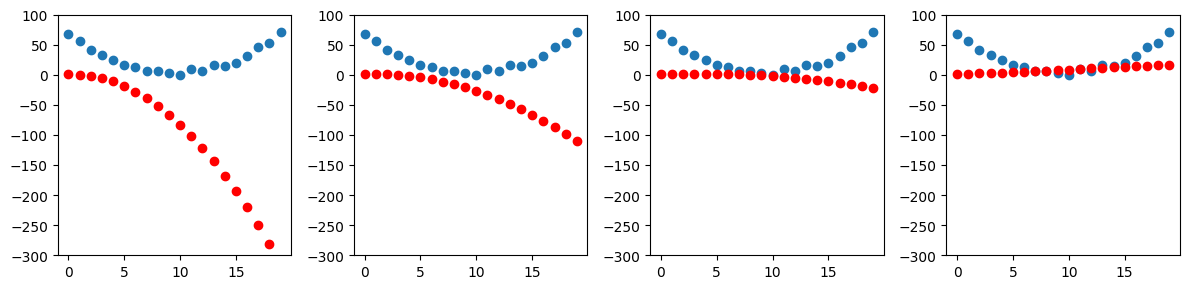

In [ ]:
_,axs = plt.subplots(1,4,figsize=(12,3))
for ax in axs: show_preds(apply_step(params, False), ax)
plt.tight_layout()

### Step 7 Stop
We just decided to stop after 10 epochs arbitrarily. In practice, we would watch the training and validation losses and our metrics to decide when to stop, as we've discussed.

---


## Summarizing Gradient Descent

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Seven steps for gradient descent process">
</div>



- At the start, the model’s weights are usually initialized randomly (when training from scratch). The model then makes predictions, which are compared with the true targets using a loss function. This function outputs a single number that measures how wrong the predictions are, and our goal is to make this number as small as possible by improving the weights.

- To adjust the weights and reduce the loss, we use calculus to compute the gradients, which measure how steeply the loss changes with respect to each weight. After clearing the previous gradients, each new call to `backward()` computes the gradients at the **current parameter values**. These gradients are then multiplied by the learning rate to control the size of each update. By repeatedly updating the weights in this way, the model gradually moves toward (or gets close to) the lowest possible loss.



### All of that we just saw can be transposed directly to the MNIST dataset, except for the loss function.

# The MNIST Loss Function

We have our **Independent variable `X`**, we will **concatenate** them into a single tensor, and change them from list of matrices a rank-3 tensor (for example: number of images × height × width). to list of vectors a rank-2 tensor using `view`, which is a PyTorch method that changes the shape of a tensor without changing its contents.

`-1` : keep this axis

`28*28` : flatten each image into 784-dimensional vector.


In [ ]:
stacked_threes.shape,stacked_sevens.shape # Rank-3 tensor

(torch.Size([6131, 28, 28]), torch.Size([6265, 28, 28]))

In [ ]:
X_train = torch.cat([stacked_threes, stacked_sevens]).view(-1, 28*28)
X_train.shape # Rank-2 tenosr

torch.Size([12396, 784])

We need a label for each image. we'll use `1` for 3s and 0 for 7s:

In [ ]:
y_train = tensor([1]*len(threes) + [0]*len(sevens)).unsqueeze(1) # ADD dim
X_train.shape,y_train.shape

(torch.Size([12396, 784]), torch.Size([12396, 1]))

A **dataset** in PyTorch is required to return a tuple of (x,y) when indexed. Python provides `zip` which combined with `list`

In [ ]:
dataset = list(zip(X_train,y_train))
x,y = dataset[0]
x.shape,y

(torch.Size([784]), tensor([1]))

In [ ]:
X_val = torch.cat([valid_threes_tens,valid_sevens_tens]).view(-1,28*28)
y_val = tensor([1]*len(valid_threes_tens) + [0]*len(valid_sevens_tens)).unsqueeze(1)
valid_dataset = list(zip(X_val,y_val))
X_val.shape,y_val.shape

(torch.Size([2038, 784]), torch.Size([2038, 1]))

Now we need to initialize weight for every pixel (STEP 1 in seven-step)

In [ ]:
def init_params(size, std=1.0): return (torch.randn(size)*std).requires_grad_()

In [ ]:
weights = init_params((28*28,1))

# We can use also : nn.parameter(torch.randn(size)*std)

weights.shape

torch.Size([784, 1])

If we use a formula like `pixel × weight`, the model is not flexible enough, because the output will always be `0` whenever the pixel value is `0`.

To make the model more flexible, we instead use a linear equation:

y = w · x + b

The bias term `b` allows the model to produce non-zero outputs even when `x = 0`. For this reason, `b` must also be initialized with a random value, just like the weight `w`.


In [ ]:
bias = init_params(1)

In neural networks,the `w` is called **Wights**, and `b` is called **Bias**. Together make up **parameters**

We can calculate one prediction for one image :

In [ ]:
(X_train[0]*weights.T).sum() + bias

tensor([-13.1868], grad_fn=<AddBackward0>)

We will use an extremely convenient mathematical operation that calculates `w*x`
for every row of a matrix, its called **matrix multiplication**

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Martix multplication page 189">
</div>



In [ ]:
def linear1(xb): return xb@weights + bias

In [ ]:
preds = linear1(X_train)
preds

tensor([[-13.1868],
        [ -8.8443],
        [-11.4937],
        ...,
        [ -5.1314],
        [  1.5329],
        [ -9.2935]], grad_fn=<AddBackward0>)

Accuracy check. To decide if an output represents a 3 or a 7, we can just check whether it's greater than 0.0

In [ ]:
corrects = (preds>0.0).float() == y_train
corrects

tensor([[False],
        [False],
        [False],
        ...,
        [ True],
        [False],
        [ True]])

In [ ]:
corrects.float().mean().item()

0.5383188128471375

Now let's see what the change in accuracy is for a small change in one of the weights
`with torch.nograd()` tells  PyTorch not to calculate the gradients

We compute gradients only when calculating the loss (during loss.backward()), not when updating the weights.


In [ ]:
with torch.no_grad(): weights[0] *= 1.0001

In [ ]:
preds = linear1(X_train)
((preds>0.0).float() == y_train).float().mean().item()

0.5383188128471375

We need **Gradients** to improve our model using SGD, and in order to calculate gradients we need **LOSS FUNCTION** that represents how good our model is, Because the gradients is a measure of "how that loss function changes when small tweaks to the weights."


The **loss function** does not receive the raw images as input. Instead, it takes the model’s `predictions`, which represent the estimated **probabilities** for each class.

The variable `prds` contains values between 0 and 1. Each value reflect how confident the model is that an image belong to a particular class (for example, class 0 or class 1), compared to the **true label**

suppose we had three images which we knew were a 3, a 7, and a 3. And suppose our model predicted with high confidence (`0.9`) that the **first was a 3**, with **slight confidence (`0.4`) that the second was a 7**, and **with fair confidence (`0.2`)**, but incorrectly, that the last was a 7. This would mean our loss function would receive these values as its inputs:

In [ ]:
trgts = tensor([1,0,1]) # True labels
prds = tensor([0.9,0.4,0.2]) # probabilities

**Loss function** that measures the distance between `Targets` and `Predictions`


`Predictons` ➡ Model output (value between 0 and 1)

`Target` ➡ True labels (0 or 1)

```python
torch.where(condition,value,value if false)
```
`torch.where()` : If target is 1, the closer prediction is to 1, the smaller the loss.

In [ ]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [ ]:
torch.where(trgts==1,1-prds,prds)

tensor([0.1000, 0.4000, 0.8000])

In [ ]:
mnist_loss(prds,trgts)

tensor(0.4460)

The function returns a smaller value when the **predictions** are closer to the **true labels**.

So, Lower loss means better predictions, not just correct predictions, but more confident and closer to the true values.

if we change our prediction for the one "false" target from `0.2` to `0.8` the loss will go down, indicating that this is a better prediction:

In [ ]:
mnist_loss(torch.tensor([0.9,0.4,0.8]),trgts)

tensor(0.3993)

# The Sigmoid Function

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Sigmoid">
</div>


It takes any input value (negative or positive), and squash it into an output between `0` and `1`



Defined as :

In [ ]:
def sigmoid(x): return 1/(1+torch.exp(-x))

Now let's apply the sigmoid function to `mnist_loss`

In [ ]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

The difference between the `LOSS Function`and `Metrics`

* **Loss function**: for the computer,It is a mathematical value that tells the optimization algorithm (like SGD) exactly how much "wrong" the model is. If we change the weight by a tiny number the cumputer can understand this little change

* **Metrich**: for human,It is a number that tells us how well the model is doing in a way that we can understand (for example: Accuracy, Precision, Recall, F1 Score)




## SGD and Mini-Batches

Details in the **Optimization step** (updating the weights based on the gradients), We need to calculate the loss over one or more data items.

How many should we use?
- We could calculate it for the whole dataset then we take the avg (It takes very long time)

- Or we calculate it for single data item (would not use much information).

Both ways would result in a very imperecise and unstable gradient

So instead we take a compromise between two: we calculate the avg loss for a few data items at a time. This called *mini-batch*. The number of data items in the mini-batch is called *batch size*.
- Larger batch size ➡ More accurate and stable estimate of you'r dataset's gradients from the loss function, But it takes more time.

As we disscused in `Chapter 2` of data augmentation, we get better **generalization** if we can vary things during the training, We want to vary the data items we put in each *mini-batches*. Rather than enumerating our dataset in order for every epoch, Instead we normally do is **randomly shuffle** it on every epoch, before we create *mini-batches*.

PyTorch and fastai provides a class that will do the shuffling and mini-batch, Called `DataLoader`

In [ ]:
coll = range(15)
dl = DataLoader(coll,batch_size=5,shuffle=True)
list(dl)

[tensor([ 9, 10, 13,  6,  8]),
 tensor([ 4,  1,  2, 12,  0]),
 tensor([14,  3,  7,  5, 11])]

In [ ]:
dl = DataLoader(coll,batch_size=5,shuffle=False)
list(dl)

[tensor([0, 1, 2, 3, 4]),
 tensor([5, 6, 7, 8, 9]),
 tensor([10, 11, 12, 13, 14])]

For training a model, we want a collection containing **independent variable `X` (Inputs)** and **dependent variable `y` (Targets)**.

Known in PyTorch as `Dataset`

EX of simple `Dataset`

In [ ]:
ds = L(enumerate(string.ascii_uppercase))
ds

[(0, 'A'), (1, 'B'), (2, 'C'), (3, 'D'), (4, 'E'), (5, 'F'), (6, 'G'), (7, 'H'), (8, 'I'), (9, 'J'), (10, 'K'), (11, 'L'), (12, 'M'), (13, 'N'), (14, 'O'), (15, 'P'), (16, 'Q'), (17, 'R'), (18, 'S'), (19, 'T'), (20, 'U'), (21, 'V'), (22, 'W'), (23, 'X'), (24, 'Y'), (25, 'Z')]

When we pass a `Dataset` to a a `DataLoader` we will get *mini-batches* which are tuples of tensors representing batches of independent and dependent variables :

In [ ]:
dl = DataLoader(ds,batch_size=5,shuffle=True)
list(dl)

[(tensor([21, 17,  2, 23, 14]), ('V', 'R', 'C', 'X', 'O')),
 (tensor([ 9, 15,  3, 24,  0]), ('J', 'P', 'D', 'Y', 'A')),
 (tensor([25, 11,  7, 18,  6]), ('Z', 'L', 'H', 'S', 'G')),
 (tensor([20, 19,  1,  4, 13]), ('U', 'T', 'B', 'E', 'N')),
 (tensor([22,  5, 12,  8, 10]), ('W', 'F', 'M', 'I', 'K')),
 (tensor([16]), ('Q',))]

---

# Putting It All Together
Implementing the process in

<div align="center">
  <img src="IMAGE SRC HERE" width="800" alt="Seven steps for gradient descent process page 174">
</div>



Our process will be implemented like :
```python
for x,y in dl:
  pred = model(x)
  loss = loss_func(pred,y)
  loss.backward()
  parameters -= parameters.grad*lr
```

In [ ]:
for x,y in dl:
  print(f"X = {x} y = {y}")

X = tensor([11,  8,  0, 18,  7]) y = ('L', 'I', 'A', 'S', 'H')
X = tensor([12, 10, 14,  1,  2]) y = ('M', 'K', 'O', 'B', 'C')
X = tensor([13, 17,  9, 20, 24]) y = ('N', 'R', 'J', 'U', 'Y')
X = tensor([25, 16, 15, 19,  5]) y = ('Z', 'Q', 'P', 'T', 'F')
X = tensor([22,  4, 21,  3, 23]) y = ('W', 'E', 'V', 'D', 'X')
X = tensor([6]) y = ('G',)


First let's re-initialize our param

In [ ]:
weights = init_params((28*28,1))

bias = init_params(1)

In [ ]:
weights.shape,bias.shape

(torch.Size([784, 1]), torch.Size([1]))

In [ ]:
dl = DataLoader(dataset,batch_size=256,shuffle=True)
xb,yb = first(dl)

In [ ]:
xb.shape,yb.shape

(torch.Size([256, 784]), torch.Size([256, 1]))

`xb shape`: 256 images flatten in vector with length 784

`yb shape`: 256 label (target)

<Axes: >

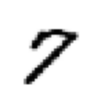

In [ ]:
im = xb[0].view(28,28)
show_image(im)

Same for Validation set

In [ ]:
valid_dl = DataLoader(valid_dataset,batch_size=256)

Example on mini-batch of size 4

In [ ]:
batch = X_train[:5]
batch.shape

torch.Size([5, 784])

In [ ]:
preds = linear1(batch)
preds

tensor([[ -5.2561],
        [ -2.9766],
        [ -7.2153],
        [-11.9705],
        [ -0.9400]], grad_fn=<AddBackward0>)

In [ ]:
loss = mnist_loss(preds,y_train[:5])
loss

tensor(0.9329, grad_fn=<MeanBackward0>)

In [ ]:
loss.backward()
weights.grad.shape,weights.grad.mean(),bias.grad

(torch.Size([784, 1]), tensor(-0.0079), tensor([-0.0508]))

All in one function:

In [ ]:
def calc_grad(xb,yb,model):
  preds = model(xb)
  loss = mnist_loss(preds,yb)
  loss.backward()

In [ ]:
calc_grad(batch,y_train[:5],linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0157), tensor([-0.1016]))

Call it again

In [ ]:
calc_grad(batch,y_train[:5],linear1)
weights.grad.mean(),bias.grad

(tensor(-0.0236), tensor([-0.1524]))

If we call it twice the gradient will change because `loss.backward()` adds the gradients of `loss` to any gradient that are currently stored, So, we have to set the current gradients to 0

> PyTorch accumulates gradients by default, so if we didn't clear them, the next iteration would add new gradients to the old ones.

In [ ]:
weights.grad.zero_()
bias.grad.zero_();

> Any methods in PyTorch ends with **underscore_** modify their objects *in place*




Our only remaining step is to update the weights and biases based on the gradient and learning rate.

In [ ]:
dl = DataLoader(dataset,batch_size=256,shuffle=True) # DataLoader

In [ ]:
x_dl,y_dl = first(dl)
len(dl),x_dl.shape,y_dl.shape

(49, torch.Size([256, 784]), torch.Size([256, 1]))

For every **batch** in the dataset, this function:

- Computes predictions

- Calculates the loss

- Computes gradients using backpropagation

- Updates the model’s parameters

- Clears gradients for the next batch

> This entire process is repeated for every batch in the DataLoader.

In [ ]:
def train_epoch(model, lr, params):
    for xb,yb in dl:
        calc_grad(xb, yb, model)
        for p in params:
            p.data -= p.grad*lr
            p.grad.zero_()

We also want to check how we're doing by looking at the accuracy of the **Validation set**

In [ ]:
((preds>0.0).float() == y_train[:5])

tensor([[False],
        [False],
        [False],
        [False],
        [False]])

In [ ]:
def linear1(xb): return xb@weights + bias

In [ ]:
def batch_accuracy(xb, yb):
    preds = xb.sigmoid()
    correct = (preds>0.5) == yb
    return correct.float().mean()

In [ ]:
batch_accuracy(linear1(batch), y_train[:5])

tensor(0.)

Calculate the accuracy for every batch in `valid_dl`

In [ ]:
def validate_epoch(model):
  accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
  return round(torch.stack(accs).mean().item(), 4)

In [ ]:
validate_epoch(linear1)

0.4718

That's our starting point, Let's train for one epoch

In [ ]:
lr = 1.
params = weights,bias
train_epoch(linear1,lr,params)
validate_epoch(linear1)

0.8767

In [ ]:
for i in range(10):
  train_epoch(linear1,lr,params)
  print(validate_epoch(linear1),end = ' ')

0.9258 0.9402 0.9495 0.9544 0.9569 0.9628 0.9647 0.9647 0.9642 0.9647 

Next, we'll create an object that will handle the **SGD** step, In PyTorch it's called *Optimizer*

### Creating an Optimizer

PyTorch provides some usefull classes to make it easier to implement like:
1. Replace `linear1` with `nn.Linear`
2. Module : is an object of a class that inherits from the PyTorch `nn.Module`

`nn.Linear` Does the same as `init_param`and 'linear1' together. It contains both *weights* and *biases* in single class

In [ ]:
linear_model = nn.Linear(28*28,1)

In [ ]:
w,b = linear_model.parameters()
w.shape,b.shape

(torch.Size([1, 784]), torch.Size([1]))

Creating the optimizer :

In [ ]:
class BasicOptim:
    def __init__(self,params,lr): self.params,self.lr = list(params),lr

    def step(self, *args, **kwargs):
        for p in self.params: p.data -= p.grad.data * self.lr

    def zero_grad(self, *args, **kwargs):
        for p in self.params: p.grad = None

In [ ]:
opt = BasicOptim(linear_model.parameters(),lr)

Our training loop can be simplified to:

In [ ]:
def train_epoch(model):
  for xb,yb in dl:
    calc_grad(xb,yb,model)
    opt.step()
    opt.zero_grad()

Test it on the same validation function

In [ ]:
def validate_epoch(model):
  accs = [batch_accuracy(model(xb), yb) for xb,yb in valid_dl]
  return round(torch.stack(accs).mean().item(), 4)

In [ ]:
validate_epoch(linear_model)

0.5439

In [ ]:
def train_model(model,epochs):
  for i in range(epochs):
    train_epoch(model)
    print(validate_epoch(model),end=" ")


In [ ]:
train_model(linear_model,20)

0.9706 0.975 0.9764 0.9764 0.9779 0.9794 0.9794 0.9794 0.9799 0.9804 0.9799 0.9809 0.9809 0.9813 0.9818 0.9823 0.9818 0.9818 0.9823 0.9838 

fastai provides `SGD` class which, by default, does the same thing as our `BasicOptim`

In [ ]:
linear_model = nn.Linear(28*28,1)
opt = SGD(linear_model.parameters(),lr)
train_model(linear_model,20)

0.974 0.9755 0.9774 0.9779 0.9789 0.9789 0.9789 0.9799 0.9794 0.9794 0.9809 0.9809 0.9804 0.9823 0.9818 0.9818 0.9823 0.9823 0.9823 0.9823 

Instead of use `train_model` fastai provides `Learner.fit`, To create a `Learner` we first need to create a `DataLoaders`, by passing in our **training** and **validation**

`DataLoaders` : is a class groups the dl and valid_dl together into a single object

In [ ]:
dl = DataLoader(dataset,batch_size=256,shuffle=True) # Training dataloader
valid_dl = DataLoader(valid_dataset,batch_size=256,shuffle=True) # Validation dataloader

In [ ]:
dls = DataLoaders(dl,valid_dl) # groups them together

A **Learner** is an object that manages the entire training process.
We must provides all the elements we've created this chapter
- the model: nn.linear(28*28,1)
- the optimization function: `SGD` from fastai
- Loss function: `mnist_loss`
- Any metrics to print: `Accuracy`


In [ ]:
def mnist_loss(predictions, targets):
    predictions = predictions.sigmoid()
    return torch.where(targets==1, 1-predictions, predictions).mean()

In [ ]:
learn = Learner(dls,nn.Linear(28*28,1),opt_func=SGD,loss_func=mnist_loss,metrics=batch_accuracy)

In [ ]:
learn.fit(10,lr=lr)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.057761,0.041750,0.970069,00:00
1,0.039685,0.034763,0.974485,00:00
2,0.032236,0.031747,0.975957,00:00
3,0.028193,0.029903,0.977429,00:00
4,0.025884,0.028519,0.977429,00:00
5,0.023768,0.026902,0.978410,00:00
6,0.022579,0.026106,0.978410,00:00
7,0.021774,0.025609,0.979392,00:00
8,0.020808,0.024941,0.980373,00:00
9,0.020039,0.024614,0.980864,00:00


# Adding a Nonlinearity
Now we have a general procedure for optimizing the parameters of a function, and we tried it on a simple linear classifier is a very constrained in term of what it can do. To make it able to handle more tasks, we need to add **Nonlinearity**

> This is what gives us Neural network

Basic definition of a basic Neural network with one hidden layer:

In [ ]:
xb.shape

torch.Size([256, 784])

In [ ]:
w1 = init_params((28*28,30))
b1 = init_params(30)
w2 = init_params((30,1))
b2 = init_params(1)

In [ ]:
def simple_net(xb):
  res = xb@w1+b1
  res = res.max(tensor(0.0))
  res = res@w2+b2
  return res

**Hidden layer : 30 output features**
Input : 784 flattened pixels
* w1 shape : (784,30)
* b1 shape : (30) one bias for every Neuron
* activation function : `ReLu, max(0,x)` allows the model to learn **non-linear patterns**

**Output layer : One output logit**
* w2 shape : (30,1)
* b2 shape : (1)


There's no point of putting two or more linear layers directly after anothre one or only one layer, because we multiply things together and then we adding them up multiple times, that could replaced with a single linear layer like :

$$f(x) = W_2(W_1x + b_1) + b_2 \implies f(x) = W'x + b'$$


But if we add a *non-linear* function between them such as `ReLu`, Now each layer can do its own useful work.


we can replace the function `simple_net` with :

In [ ]:
simple_net = nn.Sequential(
    nn.Linear(28*28,30),
    nn.ReLU(),
    nn.Linear(30,1)
)

`nn.sequential` creates a module that will call each of the listed layers in turn

In [ ]:
learn = Learner(dls,simple_net,loss_func=mnist_loss,opt_func=SGD,metrics=batch_accuracy)

In [ ]:
learn.fit(40,0.01)

epoch,train_loss,valid_loss,batch_accuracy,time
0,0.483310,0.470401,0.696271,00:00
1,0.459326,0.430749,0.912659,00:00
2,0.421547,0.374211,0.953876,00:00
3,0.367254,0.302193,0.960746,00:00
4,0.302412,0.232971,0.964671,00:00
5,0.240822,0.180616,0.963690,00:00
6,0.191390,0.145202,0.964181,00:00
7,0.155228,0.121642,0.964181,00:00
8,0.129234,0.105517,0.964181,00:00
9,0.110697,0.094012,0.964671,00:00


`learn.recorder` : contains the results of the training process over epoch, It tracks three things :    
* Training Loss
* Validation Loss
* Metrics (Accuracy)

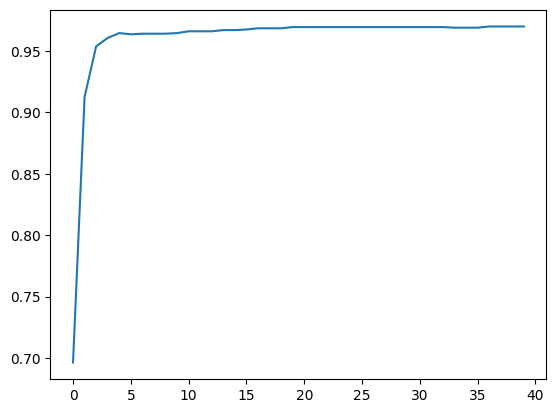

In [ ]:
plt.plot(L(learn.recorder.values).itemgot(2))

View the final accuracy

In [ ]:
learn.recorder.values[-1][2]

0.9700686931610107

### Going Deeper

There is no need to stop at just two linear layers. We can add as many as we want, as long as we add a nonlinearity between each pair of linear layers. As you will learn. The deeper the model gets, the harder it is to optimize the parameters in practice

Why do we need deeper models?
The reason is the performance.

---

# Jargon Recap






| Term            | Meaning                                                                                                   |
|-----------------|-----------------------------------------------------------------------------------------------------------|
| ReLU            | Function that returns 0 for negative numbers and doesn't change positive numbers.                        |
| Mini-batch      | A small group of inputs and labels gathered together in two arrays. A gradient descent step is updated on this batch (rather than a whole epoch). |
| Forward pass    | Applying the model to some input and computing the predictions.                                          |
| Loss            | A value that represents how well (or badly) our model is doing.                                          |
| Gradient        | The derivative of the loss with respect to some parameter of the model.                                  |
| Backward pass   | Computing the gradients of the loss with respect to all model parameters.                                |
| Gradient descent| Taking a step in the directions opposite to the gradients to make the model parameters a little bit better. |
| Learning rate   | The size of the step we take when applying SGD to update the parameters of the model.                    |

